<a href="https://colab.research.google.com/github/munawirmt/prediction-models/blob/main/LDA_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LDA** (LINEAR DISCRIMINANT ANALYSIS) ALGORITHM MODEL

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [ ]:
##load dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [ ]:
##tarin test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
##create LDA model and train
lda_classifier = LinearDiscriminantAnalysis()
lda_classifier.fit(X_train, y_train)


LinearDiscriminantAnalysis()

In [ ]:
##predict with test data
y_pred = lda_classifier.predict(X_test)


In [ ]:
##evalution
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
##diamonsionality reduction and visualize
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda_2d.fit(X, y).transform(X)


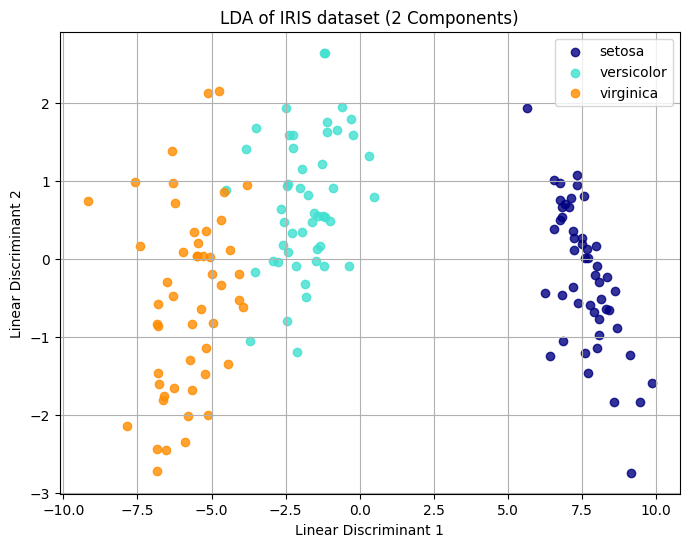

In [ ]:
##visualize LDA
plt.figure(figsize=(8, 6))
colors = ["navy", "turquoise", "darkorange"]

for color, i, target_name in zip(colors, [0,1,2],target_names):
    plt.scatter(
        X_r2[y == i, 0],
        X_r2[y == i, 1],
        alpha=0.8,
        color=color,
        label=target_name,
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.title("LDA of IRIS dataset (2 Components)")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.grid(True)
plt.show()

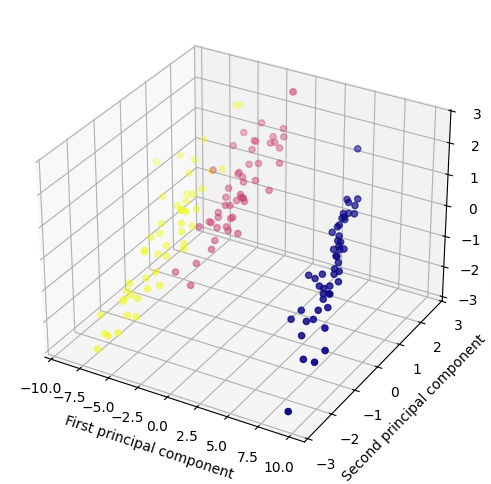

In [ ]:
##3d to 1d visualize
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(xs=X_r2[:,0],ys=X_r2[:,1],zs=X_r2[:,1],c=iris['target'],cmap='plasma')
ax.set_xlabel('First principal component')
ax.set_ylabel('Second principal component')
ax.set_zlabel('Third principal component')
plt.show()